# Clustering analysis

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1]  / "1" / "Features" 
PATIENT_PROFILES_NAME = "patient_profiles.csv"

patients = pd.read_csv(FEATURE_PATH / PATIENT_PROFILES_NAME)

In [2]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1234 entries, 0 to 1233
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     1234 non-null   float64
 1   bp_diastolic_min               1234 non-null   float64
 2   creat_max                      1234 non-null   float64
 3   heart_rate_max                 1234 non-null   float64
 4   temperature_max                1234 non-null   float64
 5   hypertension                   1234 non-null   float64
 6   k_max                          1234 non-null   float64
 7   n_admissions                   1234 non-null   float64
 8   temperature_max_measured       1234 non-null   int64  
 9   bp_measured                    1234 non-null   int64  
 10  oxygen_saturation_min          1234 non-null   float64
 11  heart_rate_max_measured        1234 non-null   int64  
 12  age                            1234 non-null   f

In [3]:
missing_cols = patients.columns[patients.isna().sum() > 0]
print(missing_cols)


Index([], dtype='object')


In [4]:
patients_missing = patients[missing_cols]
patients_missing.head()

""
0
1
2
3
4


## Normalization

Before digging into the clustering analysis, we have to normalize the data we've obtained in the previous task. 

We use `scikit-learn` tools to scale the features.

In [5]:
!pip install scikit-learn

In [6]:
patients.head()

,subject_id,bp_diastolic_min,creat_max,heart_rate_max,temperature_max,hypertension,k_max,n_admissions,temperature_max_measured,bp_measured,...,severity_max,severity_mean,k_min,k_abnormal,hyperglycemia,bp_systolic_max,respiratory_rate_max,num_vitals_measured,procedures_avg,glu_max
0,10000980.0,103.0,1.516575,65.0,2.121320,0.107673,4.5,0.031197,1,1,...,5.0,2.200,4.2,0,1,200.0,5.099020,7.0,2.645751,12.767145
1,10004457.0,80.1,1.000000,73.3,2.073644,0.000000,5.1,0.031197,0,0,...,5.0,0.875,5.1,1,0,124.4,4.195235,0.0,1.807761,9.591663
2,10007058.0,71.0,1.000000,63.0,2.097618,0.000000,4.1,0.031197,1,1,...,3.0,0.900,3.5,0,0,123.0,4.582576,7.0,1.414214,10.535654
3,10018684.0,84.0,1.048809,67.6,1.949359,0.000000,4.6,0.031197,0,0,...,3.0,1.375,4.0,0,0,133.0,4.086563,0.0,1.849865,9.899495
4,10044096.0,87.0,0.948683,66.0,2.121320,0.000000,4.3,0.031197,1,1,...,3.0,1.167,3.9,0,0,113.0,3.316625,7.0,2.236068,9.848858


We delete the `subject_id` column for the clustering part.

In [7]:
X = patients.drop(columns=['subject_id'])
X.head()

,bp_diastolic_min,creat_max,heart_rate_max,temperature_max,hypertension,k_max,n_admissions,temperature_max_measured,bp_measured,oxygen_saturation_min,...,severity_max,severity_mean,k_min,k_abnormal,hyperglycemia,bp_systolic_max,respiratory_rate_max,num_vitals_measured,procedures_avg,glu_max
0,103.0,1.516575,65.0,2.121320,0.107673,4.5,0.031197,1,1,100.0,...,5.0,2.200,4.2,0,1,200.0,5.099020,7.0,2.645751,12.767145
1,80.1,1.000000,73.3,2.073644,0.000000,5.1,0.031197,0,0,98.0,...,5.0,0.875,5.1,1,0,124.4,4.195235,0.0,1.807761,9.591663
2,71.0,1.000000,63.0,2.097618,0.000000,4.1,0.031197,1,1,99.0,...,3.0,0.900,3.5,0,0,123.0,4.582576,7.0,1.414214,10.535654
3,84.0,1.048809,67.6,1.949359,0.000000,4.6,0.031197,0,0,97.0,...,3.0,1.375,4.0,0,0,133.0,4.086563,0.0,1.849865,9.899495
4,87.0,0.948683,66.0,2.121320,0.000000,4.3,0.031197,1,1,100.0,...,3.0,1.167,3.9,0,0,113.0,3.316625,7.0,2.236068,9.848858


We use Hybrid scaling cause we have mixed data (binary and continuous features)

In [8]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer


binary_cols = []
continuous_cols = []

for col in X.columns:
    unique_vals = X[col].nunique()
    if unique_vals <= 2:
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"\nBinary features: {len(binary_cols)}")
print(binary_cols[:10])
print(f"\nContinuous features: {len(continuous_cols)}")
print(continuous_cols[:10])

# Create hybrid scaler
preprocessor = ColumnTransformer(
    transformers=[
        ('binary', StandardScaler(), binary_cols),       
        ('continuous', RobustScaler(), continuous_cols)  
    ]
)

X_scaled = preprocessor.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=binary_cols + continuous_cols, index=X.index)


Binary features: 9
['hypertension', 'n_admissions', 'temperature_max_measured', 'bp_measured', 'heart_rate_max_measured', 'gender', 'respiratory_rate_max_measured', 'k_abnormal', 'hyperglycemia']

Continuous features: 15
['bp_diastolic_min', 'creat_max', 'heart_rate_max', 'temperature_max', 'k_max', 'oxygen_saturation_min', 'age', 'severity_max', 'severity_mean', 'k_min']



Components to keep 95% variance: 17
Original features: 24

✅ PCA completed
   Reduced dimensions: 17
   Variance explained: 95.07%


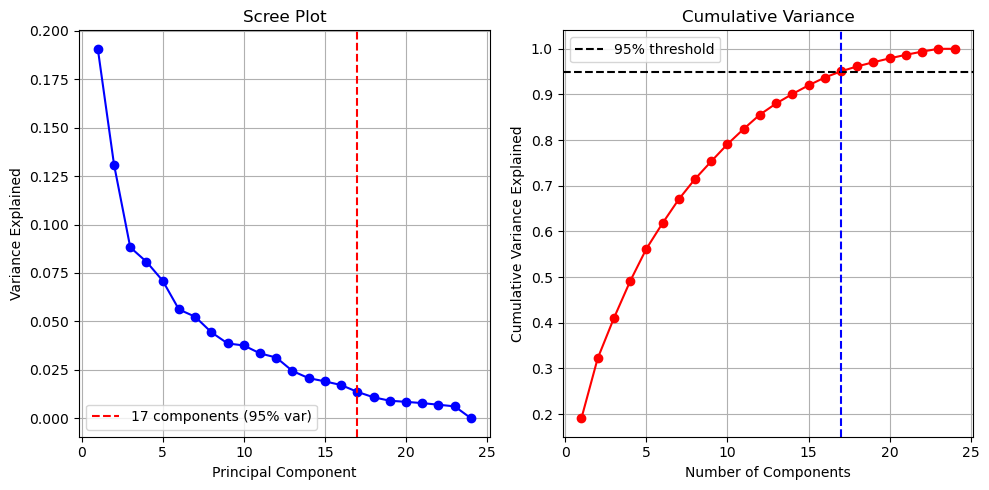

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 

# Determine optimal number of components (keep 95% variance)
pca_full = PCA()
pca_full.fit(X_scaled)

cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumsum_var >= 0.95) + 1

print(f"\nComponents to keep 95% variance: {n_components}")
print(f"Original features: {X_scaled.shape[1]}")

# Apply PCA
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\n✅ PCA completed")
print(f"   Reduced dimensions: {X_pca.shape[1]}")
print(f"   Variance explained: {cumsum_var[n_components-1]:.2%}")

# Plot scree plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
         pca_full.explained_variance_ratio_, 'bo-')
plt.axvline(n_components, color='r', linestyle='--', label=f'{n_components} components (95% var)')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'ro-')
plt.axhline(0.95, color='k', linestyle='--', label='95% threshold')
plt.axvline(n_components, color='b', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


K-MEANS WITH IMPROVED FEATURES
k=2 | Silhouette=0.185 | Davies-Bouldin=2.086 | CH=265.2
k=3 | Silhouette=0.124 | Davies-Bouldin=2.268 | CH=185.8
k=4 | Silhouette=0.140 | Davies-Bouldin=2.259 | CH=173.7
k=5 | Silhouette=0.130 | Davies-Bouldin=2.134 | CH=154.7
k=6 | Silhouette=0.125 | Davies-Bouldin=2.196 | CH=142.5
k=7 | Silhouette=0.129 | Davies-Bouldin=2.093 | CH=133.2
k=8 | Silhouette=0.117 | Davies-Bouldin=2.038 | CH=124.0
k=9 | Silhouette=0.112 | Davies-Bouldin=2.105 | CH=114.3
k=10 | Silhouette=0.112 | Davies-Bouldin=2.059 | CH=107.4

🏆 Best k (by Silhouette): 2
   Silhouette Score: 0.185


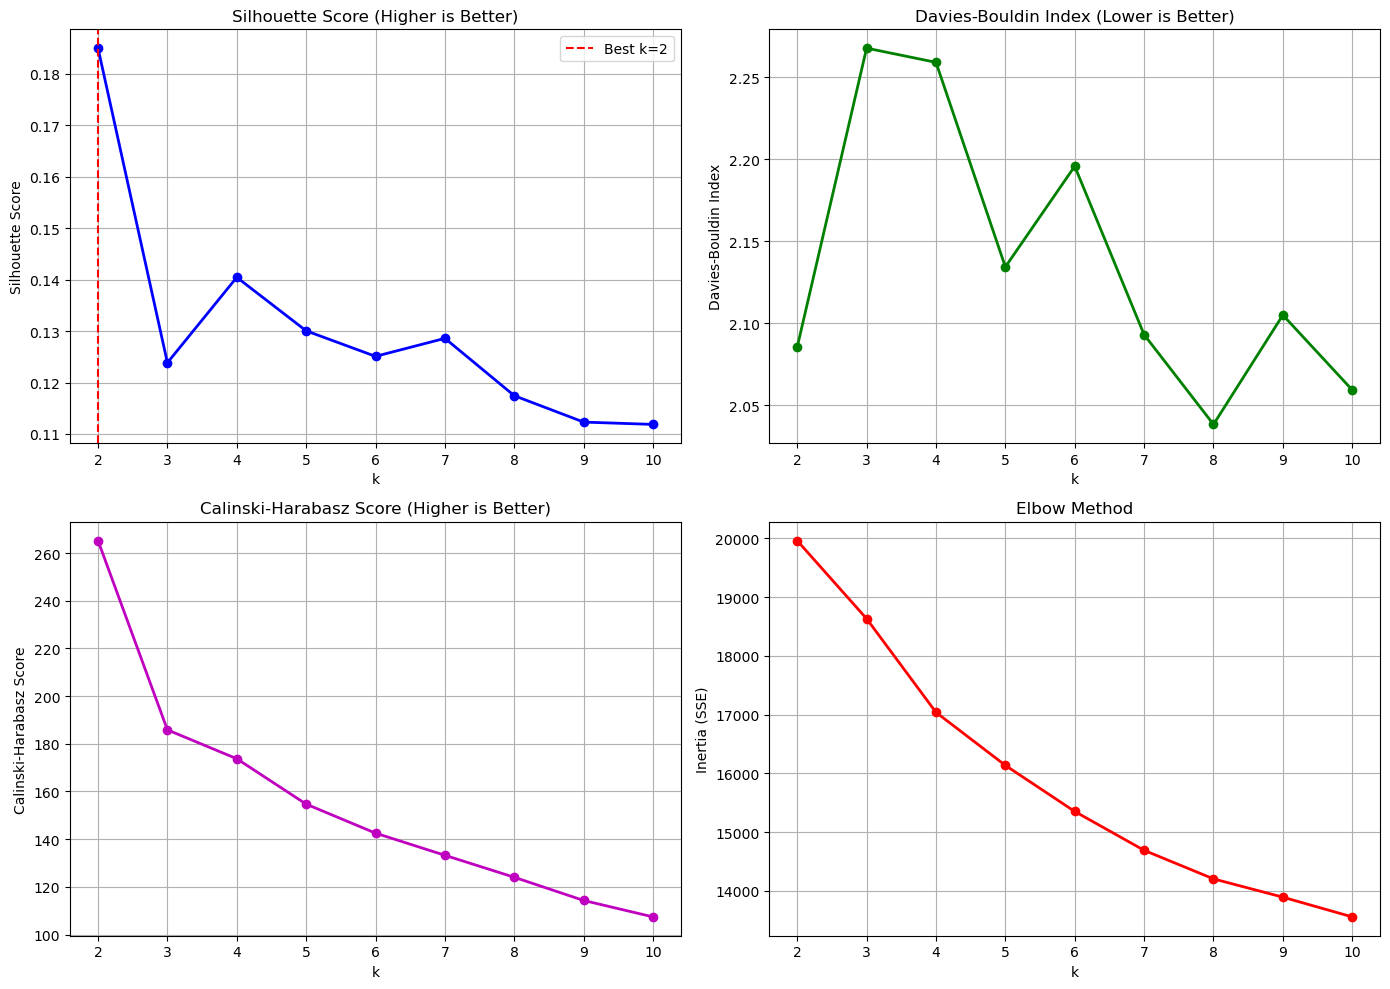

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("\n" + "="*80)
print("K-MEANS WITH IMPROVED FEATURES")
print("="*80)

K_range = range(2, 11)
results = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X_pca)
    
    sil = silhouette_score(X_pca, labels)
    db = davies_bouldin_score(X_pca, labels)
    ch = calinski_harabasz_score(X_pca, labels)
    
    results.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'inertia': kmeans.inertia_
    })
    
    print(f"k={k} | Silhouette={sil:.3f} | Davies-Bouldin={db:.3f} | CH={ch:.1f}")

# Find best k
results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['silhouette'].idxmax(), 'k']

print(f"\n🏆 Best k (by Silhouette): {int(best_k)}")
print(f"   Silhouette Score: {results_df[results_df['k']==best_k]['silhouette'].values[0]:.3f}")

# Plot metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Silhouette
axes[0, 0].plot(results_df['k'], results_df['silhouette'], 'bo-', linewidth=2)
axes[0, 0].axvline(best_k, color='r', linestyle='--', label=f'Best k={int(best_k)}')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].set_title('Silhouette Score (Higher is Better)')
axes[0, 0].grid(True)
axes[0, 0].legend()

# Davies-Bouldin
axes[0, 1].plot(results_df['k'], results_df['davies_bouldin'], 'go-', linewidth=2)
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Davies-Bouldin Index')
axes[0, 1].set_title('Davies-Bouldin Index (Lower is Better)')
axes[0, 1].grid(True)

# Calinski-Harabasz
axes[1, 0].plot(results_df['k'], results_df['calinski_harabasz'], 'mo-', linewidth=2)
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')
axes[1, 0].set_title('Calinski-Harabasz Score (Higher is Better)')
axes[1, 0].grid(True)

# Elbow
axes[1, 1].plot(results_df['k'], results_df['inertia'], 'ro-', linewidth=2)
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('Inertia (SSE)')
axes[1, 1].set_title('Elbow Method')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


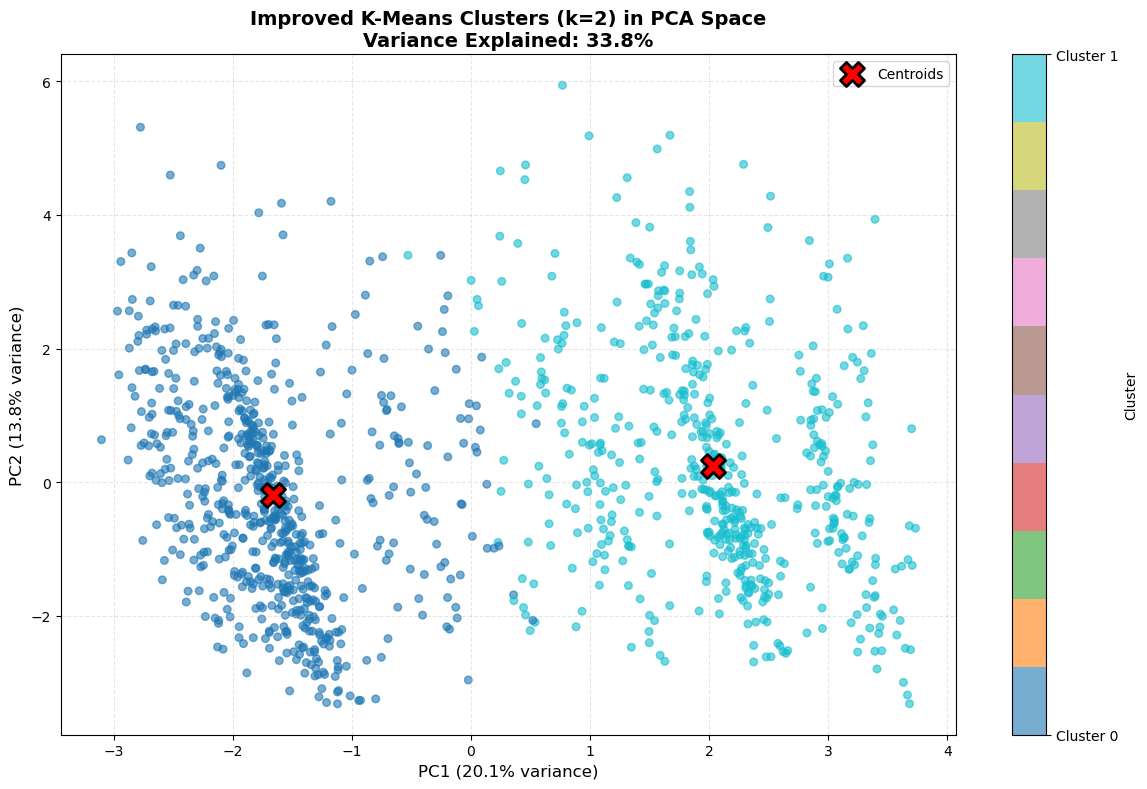


📊 Cluster Distribution:
cluster_improved
0    679
1    555
Name: count, dtype: int64


In [11]:
# Final clustering with best k
kmeans_final = KMeans(n_clusters=int(best_k), random_state=42, n_init=20)
labels_final = kmeans_final.fit_predict(X_pca)

# Add labels to original dataframe
patients['cluster_improved'] = labels_final

# Visualize in 2D PCA space
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_pca)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                      c=labels_final, cmap='tab10', alpha=0.6, s=30)

# Plot centroids
centroids_2d = pca_2d.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], 
            c='red', marker='X', s=300, edgecolors='black', linewidth=2, 
            label='Centroids', zorder=10)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'Improved K-Means Clusters (k={int(best_k)}) in PCA Space\nVariance Explained: {pca_2d.explained_variance_ratio_.sum():.1%}', 
          fontsize=14, fontweight='bold')

cbar = plt.colorbar(scatter, label='Cluster')
cbar.set_ticks(np.arange(int(best_k)))
cbar.set_ticklabels([f'Cluster {i}' for i in range(int(best_k))])

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Cluster sizes
print("\n📊 Cluster Distribution:")
print(patients['cluster_improved'].value_counts().sort_index())


## Clustering analysis: K-means

### Find the best K

#### Knee method

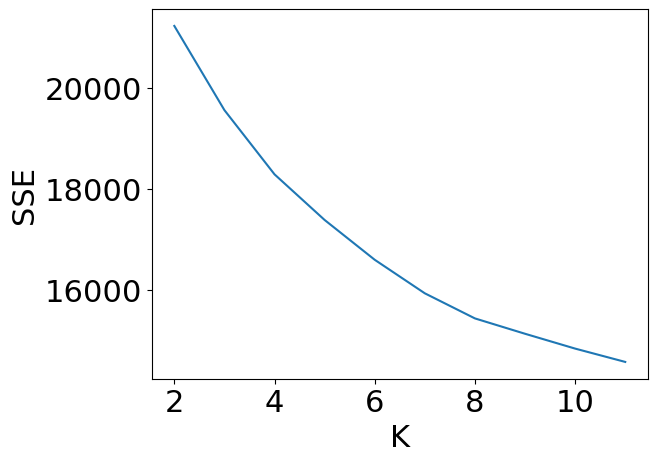

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse_list = list()
max_k = 11
for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100)
    kmeans.fit(X_scaled)
    
    sse = kmeans.inertia_
    sse_list.append(sse)

plt.plot(range(2, len(sse_list) + 2), sse_list)
plt.ylabel('SSE', fontsize=22)
plt.xlabel('K', fontsize=22)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.show()

#### Silhouette score

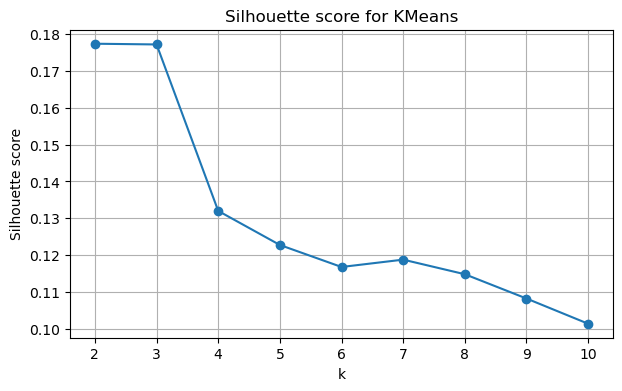

Best k by silhouette: 2


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Range of k to try
K = range(2, 11)

sil_scores = []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Silhouette plot
plt.figure(figsize=(7, 4))
plt.plot(K, sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette score for KMeans')
plt.xticks(list(K))
plt.grid(True)
plt.show()

best_k = K[sil_scores.index(max(sil_scores))]
print("Best k by silhouette:", best_k)


### Characterizations of the clusters 

In [14]:
k_opt = best_k  
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

# Attach cluster labels to the patient dataframe
patients['cluster_kmeans'] = cluster_labels
patients[['subject_id', 'cluster_kmeans']].head()


,subject_id,cluster_kmeans
0,10000980.0,1
1,10004457.0,0
2,10007058.0,1
3,10018684.0,0
4,10044096.0,1


In [15]:
cluster_profile = patients.groupby('cluster_kmeans').mean(numeric_only=True)
cluster_profile

,subject_id,bp_diastolic_min,creat_max,heart_rate_max,temperature_max,hypertension,k_max,n_admissions,temperature_max_measured,bp_measured,...,severity_mean,k_min,k_abnormal,hyperglycemia,bp_systolic_max,respiratory_rate_max,num_vitals_measured,procedures_avg,glu_max,cluster_improved
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,
0,1.494927e+07,74.692353,1.142236,78.810441,2.251783,0.000475,4.638422,0.031197,0.130882,0.033824,...,1.488691,3.768971,0.352941,0.489706,130.215000,4.343425,0.320588,1.873454,12.395940,0.001471
1,1.492992e+07,75.239892,1.122422,79.744585,2.140206,0.036344,4.566830,0.031197,0.889892,0.944043,...,1.447397,3.755596,0.324910,0.458484,132.642599,4.333994,6.462094,1.835232,12.246278,1.000000


### Evaluation of clustering results

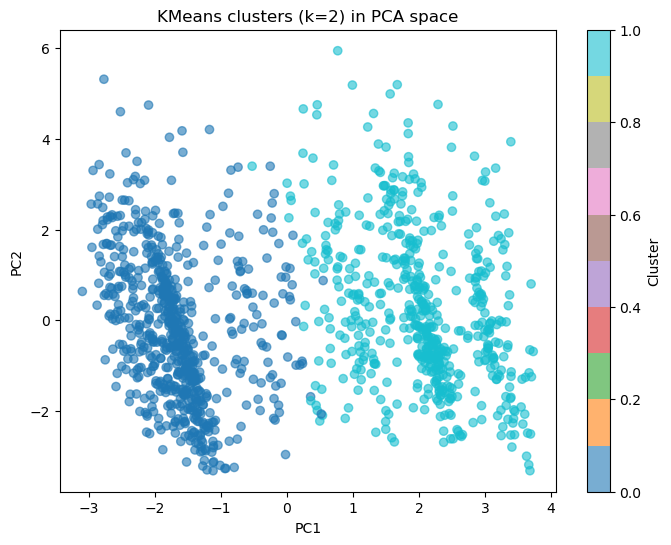

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap='tab10',
    alpha=0.6
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'KMeans clusters (k={k_opt}) in PCA space')
plt.colorbar(scatter, label='Cluster')
plt.show()


/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/tmp/ipykernel_66725/3633482065.py:21: UserWarning: Adding colorbar to a different Figure <Figure size 800x600 with 3 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(scatter, label='Cluster', ticks=np.arange(k_opt))


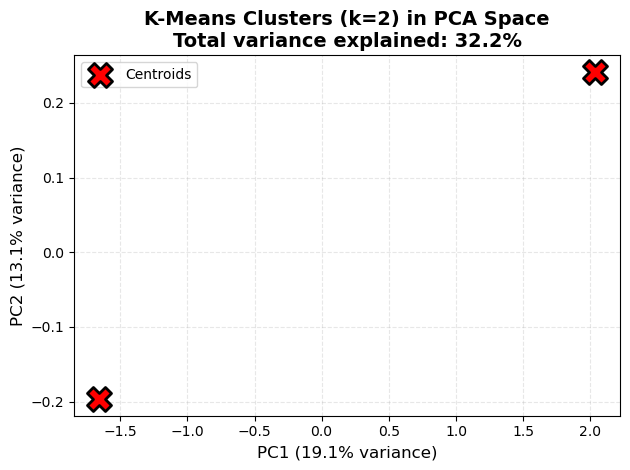

In [17]:
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='red',
    marker='X',
    s=300,
    edgecolors='black',
    linewidth=2,
    label='Centroids',
    zorder=10  # Porta i centroidi in primo piano
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'K-Means Clusters (k={k_opt}) in PCA Space\nTotal variance explained: {pca.explained_variance_ratio_.sum():.1%}', 
          fontsize=14, fontweight='bold')

# CHIAVE: Colorbar DISCRETA invece di continua
cbar = plt.colorbar(scatter, label='Cluster', ticks=np.arange(k_opt))
cbar.set_label('Cluster', fontsize=12)
cbar.ax.set_yticklabels([f'Cluster {i}' for i in range(k_opt)])  # Etichette esplicite

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

**Possible interpretation**

With `k=2`, the clusters essentially represent two broad cardiometabolic risk profiles.

**Cluster 0 (healthier/lower risk)**
Younger patients, with lower hf_severity_max, fewer comorbidities (e.g., lv_dilated, atrial_fibrillation ≈ 0), and fewer total procedures/lab events.

**Cluster 1 (more complex/higher risk)**
Older patients, with higher blood pressure, heart rate, and hf_severity_max, a greater presence of structural comorbidities, and a higher number of tests/procedures; these are the "high-intensity care" patients.

## Clustering analysis: Density-based clustering (DBSCAN)

Before doing the analysis, we tune the hyperparameters (`eps`, `min_samples`) with a grid search. 

In [18]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

eps_values = [1.0, 5.0, 10.0, 15.0]
min_samples_values = [1,3,5]

best_eps = None
best_min_samples = None
best_sil = -1.0
best_labels = None

results = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        if n_clusters >= 2 and n_noise < len(labels):
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask])
        else:
            sil = np.nan

        results.append((eps, ms, n_clusters, n_noise, sil))

        # update best combination
        if not np.isnan(sil) and sil > best_sil:
            best_sil = sil
            best_eps = eps
            best_min_samples = ms
            best_labels = labels

# print all results
for r in results:
    print(f"eps={r[0]:.2f}, min_samples={r[1]:2d} -> "
          f"clusters={r[2]}, noise={r[3]}, silhouette={r[4]}")

print("\nBest combination:")
print(f"eps={best_eps}, min_samples={best_min_samples}, silhouette={best_sil}")

eps=1.00, min_samples= 1 -> clusters=1231, noise=0, silhouette=0.0015448405245650743
eps=1.00, min_samples= 3 -> clusters=1, noise=1231, silhouette=nan
eps=1.00, min_samples= 5 -> clusters=0, noise=1234, silhouette=nan
eps=5.00, min_samples= 1 -> clusters=9, noise=0, silhouette=0.12793979993148522
eps=5.00, min_samples= 3 -> clusters=1, noise=9, silhouette=nan
eps=5.00, min_samples= 5 -> clusters=1, noise=9, silhouette=nan
eps=10.00, min_samples= 1 -> clusters=1, noise=0, silhouette=nan
eps=10.00, min_samples= 3 -> clusters=1, noise=0, silhouette=nan
eps=10.00, min_samples= 5 -> clusters=1, noise=0, silhouette=nan
eps=15.00, min_samples= 1 -> clusters=1, noise=0, silhouette=nan
eps=15.00, min_samples= 3 -> clusters=1, noise=0, silhouette=nan
eps=15.00, min_samples= 5 -> clusters=1, noise=0, silhouette=nan

Best combination:
eps=5.0, min_samples=1, silhouette=0.12793979993148522


In [19]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
db_labels = dbscan.fit_predict(X_scaled)

patients['cluster_dbscan'] = db_labels  # save labels (-1 = noise)

# --- basic stats ---
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = np.sum(db_labels == -1)

print(f"DBSCAN - number of clusters (excluding noise): {n_clusters_db}")
print(f"DBSCAN - number of noise points: {n_noise_db}")

# silhouette only if at least 2 clusters and not all noise
if n_clusters_db >= 2:
    mask_core = db_labels != -1
    sil_db = silhouette_score(X_scaled[mask_core], db_labels[mask_core])
    print(f"DBSCAN silhouette (without noise): {sil_db:.3f}")
else:
    print("Silhouette not meaningful (less than 2 clusters).")


DBSCAN - number of clusters (excluding noise): 9
DBSCAN - number of noise points: 0
DBSCAN silhouette (without noise): 0.128


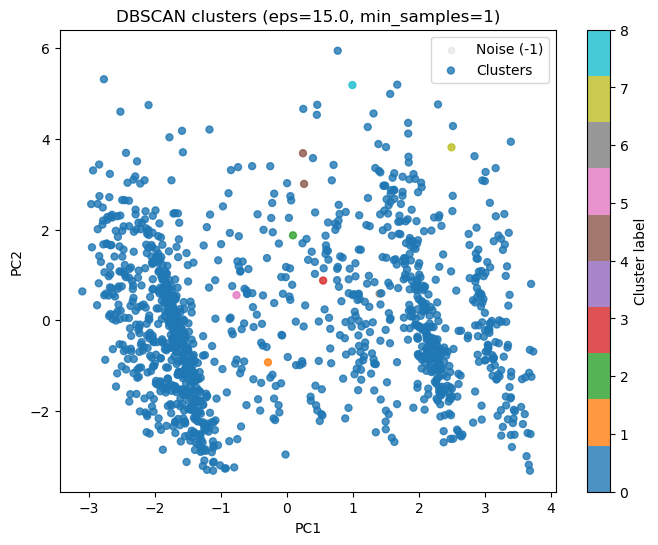

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

mask_noise = db_labels == -1
mask_cluster = ~mask_noise

# noise in grey
plt.scatter(
    X_pca[mask_noise, 0],
    X_pca[mask_noise, 1],
    c='lightgrey',
    s=20,
    alpha=0.4,
    label='Noise (-1)'
)

# clusters with colors
scatter = plt.scatter(
    X_pca[mask_cluster, 0],
    X_pca[mask_cluster, 1],
    c=db_labels[mask_cluster],
    cmap='tab10',
    s=25,
    alpha=0.8,
    label='Clusters'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN clusters (eps={eps}, min_samples={best_min_samples})')
plt.legend()
plt.colorbar(scatter, label='Cluster label')
plt.show()


In [21]:
dbscan_profile = (
    patients[patients['cluster_dbscan'] != -1]
    .groupby('cluster_dbscan')
    .mean(numeric_only=True)
    .round(2)
)

display(dbscan_profile)

# cluster sizes
patients['cluster_dbscan'].value_counts().sort_index()

,subject_id,bp_diastolic_min,creat_max,heart_rate_max,temperature_max,hypertension,k_max,n_admissions,temperature_max_measured,bp_measured,...,k_min,k_abnormal,hyperglycemia,bp_systolic_max,respiratory_rate_max,num_vitals_measured,procedures_avg,glu_max,cluster_improved,cluster_kmeans
cluster_dbscan,,,,,,,,,,,,,,,,,,,,,
0,14948709.77,74.94,1.13,79.12,2.20,0.02,4.60,0.03,0.47,0.44,...,3.76,0.34,0.47,131.23,4.34,3.06,1.85,12.32,0.45,0.45
1,10112698.00,90.00,0.89,60.10,3.35,0.11,4.00,0.03,1.00,1.00,...,3.70,0.00,0.00,180.00,4.38,5.00,3.46,10.82,0.00,0.00
2,10345163.00,82.00,1.73,68.20,2.32,0.11,5.80,0.03,0.00,1.00,...,4.00,1.00,0.00,163.00,4.18,4.00,2.74,11.66,0.00,0.00
3,10820804.00,77.30,1.73,65.70,1.00,0.00,5.80,0.03,1.00,0.00,...,5.00,1.00,1.00,138.20,4.27,1.00,3.32,16.28,0.00,0.00
4,13597948.50,77.00,1.14,82.50,3.35,0.00,5.05,0.03,1.00,1.00,...,3.50,1.00,1.00,115.50,4.30,7.00,2.03,12.87,1.00,1.00
5,14312658.00,63.80,1.58,200.00,2.07,0.00,4.70,0.03,0.00,0.00,...,4.30,0.00,1.00,123.30,4.28,1.00,2.25,13.34,0.00,0.00
6,16459432.00,74.00,1.73,104.00,1.97,0.11,4.60,0.03,0.00,1.00,...,3.70,0.00,1.00,175.00,4.22,5.00,2.28,13.75,1.00,1.00
7,16762272.00,71.00,1.55,92.00,2.14,0.11,5.50,0.03,1.00,1.00,...,3.90,1.00,1.00,183.00,5.10,7.00,1.00,17.93,1.00,1.00
8,18499078.00,62.00,1.41,93.00,2.19,0.00,4.50,0.03,1.00,1.00,...,2.90,1.00,1.00,76.00,6.32,7.00,2.65,17.93,1.00,1.00


cluster_dbscan
0    1225
1       1
2       1
3       1
4       2
5       1
6       1
7       1
8       1
Name: count, dtype: int64

## Clustering analysis: Hierarchical clustering

In [22]:
from scipy.stats import mode
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

#### Complete linkage

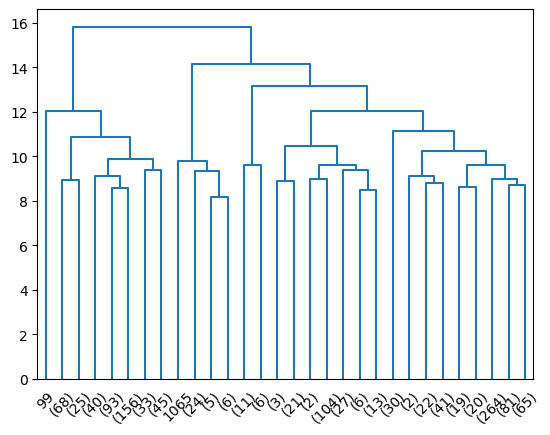

In [23]:
data_dist = pdist(X_scaled, metric='euclidean')
data_link = linkage(data_dist, method='complete', metric='euclidean')
res = dendrogram(data_link, color_threshold=1.0, truncate_mode='lastp')

#### Single link

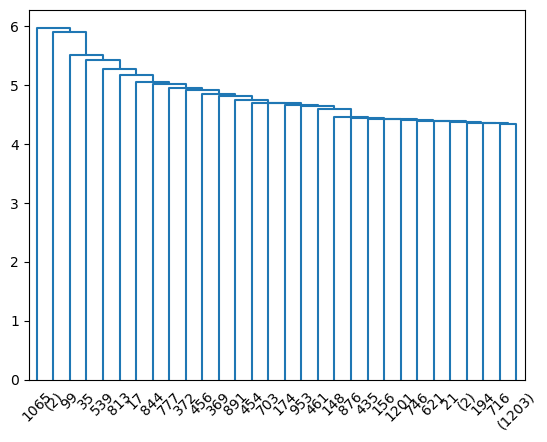

In [24]:
data_dist = pdist(X_scaled, metric='euclidean')
data_link = linkage(data_dist, method='single', metric='euclidean')
res = dendrogram(data_link, color_threshold=0.2, truncate_mode='lastp')

#### Average

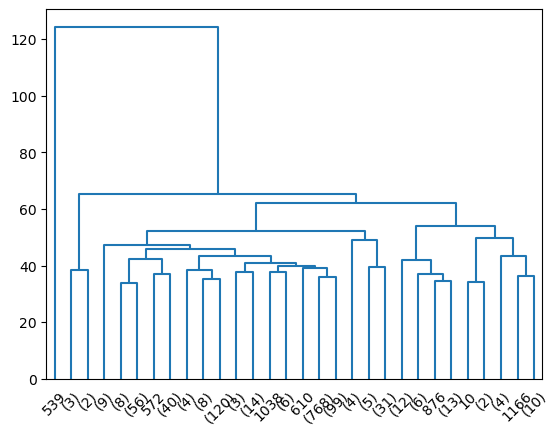

In [25]:
data_dist = pdist(X, metric='euclidean')
data_link = linkage(data_dist, method='average', metric='euclidean')
res = dendrogram(data_link, color_threshold=0.4, truncate_mode='lastp')

In [26]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

linkages = ['ward', 'complete', 'average']
K = range(2, 11)

results_hc = []
best_link = None
best_k = None
best_sil = -1
best_labels = None

for link in linkages:
    for k in K:
        if link == 'ward':
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage='ward'
            )
        else:
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage=link,
                metric='euclidean'
            )

        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)

        results_hc.append((link, k, sil))
        print(f"linkage={link:8s}, k={k} -> silhouette={sil:.3f}")

        if sil > best_sil:
            best_sil = sil
            best_link = link
            best_k = k
            best_labels = labels

print("\nBest hierarchical configuration:")
print(f"linkage={best_link}, k={best_k}, silhouette={best_sil:.3f}")

patients['cluster_hier'] = best_labels


linkage=ward    , k=2 -> silhouette=0.163
linkage=ward    , k=3 -> silhouette=0.175
linkage=ward    , k=4 -> silhouette=0.166
linkage=ward    , k=5 -> silhouette=0.128
linkage=ward    , k=6 -> silhouette=0.099
linkage=ward    , k=7 -> silhouette=0.102
linkage=ward    , k=8 -> silhouette=0.104
linkage=ward    , k=9 -> silhouette=0.109
linkage=ward    , k=10 -> silhouette=0.094
linkage=complete, k=2 -> silhouette=0.051
linkage=complete, k=3 -> silhouette=0.053
linkage=complete, k=4 -> silhouette=0.054
linkage=complete, k=5 -> silhouette=0.053
linkage=complete, k=6 -> silhouette=0.098
linkage=complete, k=7 -> silhouette=0.085
linkage=complete, k=8 -> silhouette=0.057
linkage=complete, k=9 -> silhouette=0.060
linkage=complete, k=10 -> silhouette=0.058
linkage=average , k=2 -> silhouette=0.432
linkage=average , k=3 -> silhouette=0.312
linkage=average , k=4 -> silhouette=0.249
linkage=average , k=5 -> silhouette=0.192
linkage=average , k=6 -> silhouette=0.167
linkage=average , k=7 -> silhoue

In [27]:
hc = AgglomerativeClustering(
    n_clusters=best_k,
    linkage=best_link,
    metric='euclidean' if best_link != 'ward' else None
)
hc_labels = hc.fit_predict(X_scaled)

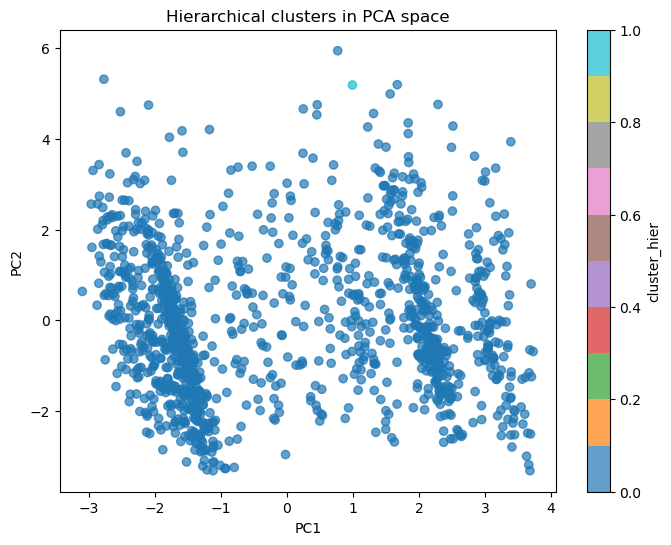

In [28]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hc_labels,        
    cmap='tab10',
    alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Hierarchical clusters in PCA space')
plt.colorbar(scatter, label='cluster_hier')
plt.show()

## Final evaluation

To be done

## **Optional**: alternative clustering

We use `pyclustering` to explore other various type of clustering.  

In [29]:
!pip install pyclustering

### X-means

`X-means` can provide useful information. It extends KMeans and automatically chooses the number of clusters using BIC-like criteria (*Bayesian Information Criterion*).

In [30]:
from pyclustering.cluster.xmeans import xmeans, kmeans_plusplus_initializer
import numpy as np
import warnings
np.warnings = warnings

data = X_scaled.values

initial_centers = kmeans_plusplus_initializer(
    data,
    amount_centers=2      # starting k (e.g. 2)
).initialize()

xmeans_instance = xmeans(
    data=data,
    initial_centers=initial_centers,
    kmax=10               # maximum clusters to search
)

xmeans_instance.process()

clusters = xmeans_instance.get_clusters()       # list of lists of indices
centers  = xmeans_instance.get_centers()

print(f"Found {len(clusters)} clusters")


Found 9 clusters


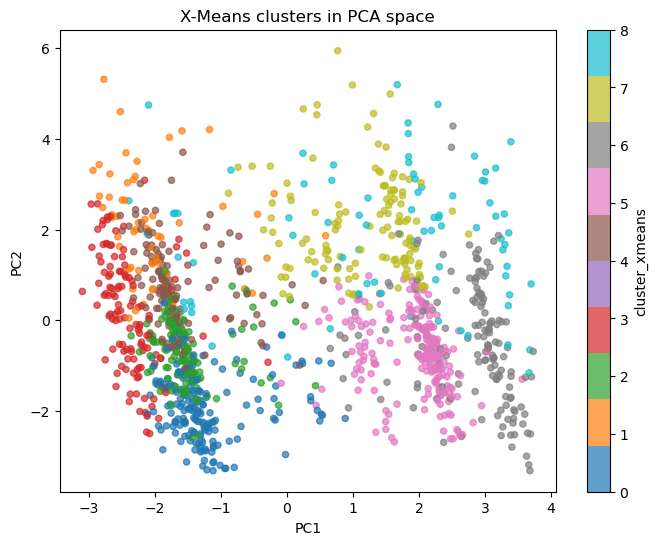

In [31]:
labels_xmeans = np.empty(data.shape[0], dtype=int)
for idx_cluster, indices in enumerate(clusters):
    labels_xmeans[indices] = idx_cluster

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=labels_xmeans, cmap='tab10', alpha=0.7, s=20)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('X-Means clusters in PCA space')
plt.colorbar(scatter, label='cluster_xmeans')
plt.show()